# Introduction

This notebook was developed by **Kaveh Kasaee**, a Senior AI/ML Engineer, to analyze sensor data collected from **1,600 machine breakdown events**. Out of these, only **40 cases have been labeled by domain experts**, creating a significant gap between available data and labeled information.

The objective of this analysis is to leverage the limited labeled data to extract meaningful insights from the remaining unlabeled cases. To achieve this, a **hybrid semi-supervised approach** is applied, combining machine learning techniques with similarity-based validation to:

- Extend labels to a large portion of the dataset  
- Identify consistent patterns in sensor behavior  
- Uncover hidden structure and relationships within the data  

This approach enables both **scaling expert knowledge** and **discovering new insights** from previously unused data.

### importing the needed packages for the whole notebook

In [51]:
# Data manipulation and numerical operations
import pandas as pd  # Data handling
import numpy as np   # Numerical computations

# Visualization
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Advanced visualization

# Mathematical functions
import math  # Common math operations

# Feature selection and statistical analysis
from sklearn.feature_selection import f_classif  # ANOVA test
from scipy.stats import ks_2samp                 # KS test (distribution comparison)

# Machine learning models and evaluation
from sklearn.ensemble import RandomForestClassifier  # Random Forest model
from sklearn.linear_model import LogisticRegression  # Logistic Regression
from sklearn.metrics import accuracy_score           # Accuracy evaluation
from sklearn.model_selection import LeaveOneOut      # Leave-One-Out Cross-Validation (LOOCV)

# Dimensionality reduction and scaling
from sklearn.manifold import TSNE              # t-SNE for clusters visualization
from sklearn.decomposition import PCA          # Principal Component Analysis
from sklearn.preprocessing import StandardScaler  # Feature scaling

# Clustering and similarity
from sklearn.metrics.pairwise import cosine_similarity  # Cosine similarity
from sklearn.cluster import KMeans                      # K-Means clustering

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")


### Reading the csv file and deviding the data into two groups: labeled and unlabeled

In [2]:
df = pd.read_csv('data_sensors.csv')
labeled_df = df[df["Label"].notna()].copy()
unlabeled_df = df[df["Label"].isna()].copy()

## EDA 

### defining a function which is reusable for drawing a pie chart: the distribution of the labels 

In [4]:
def plot_pie_chart(df, column_name, chart_title="Pie Chart"):
    """
    Generates a pie chart that consistently maintains the order of slices and uses consistent colors for labels.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the column to create a pie chart for.
        chart_title (str): The title of the chart (default is "Pie Chart").
    """
    # Define a fixed order for the labels and their corresponding colors
    fixed_order = [1, 2, 3]
    color_mapping = {
        1: '#99ff99',  # Green for label 1
        2: '#66b3ff',  # Blue for label 2
        3: '#ff9999'   # Red for label 3
    }
    
    # Get value counts for the column and set missing labels' counts to 0
    value_counts = df[column_name].value_counts()
    value_counts = value_counts.reindex(fixed_order, fill_value=0)  # Ensure fixed order
    
    # Map colors based on the fixed order
    colors = [color_mapping[label] for label in fixed_order]
    
    # Create the pie chart
    plt.figure(figsize=(8, 8))
    value_counts.plot(
        kind='pie',
        autopct=lambda p: '{:.0f}%'.format(p),   # Show integer percentages
        startangle=90,                           # Start chart from a specific angle
        colors=colors,                           # Use consistent colors
        explode=[0.05] * len(value_counts),      # Slightly "explode" slices
        shadow=True                              # Add shadow for 3D effect
    )
    
    # Add title and other details to the chart
    plt.title(chart_title, fontsize=16)
    plt.ylabel("")  # Remove y-axis label for clarity
    plt.tight_layout()
    
    # Show the plot
    plt.show()

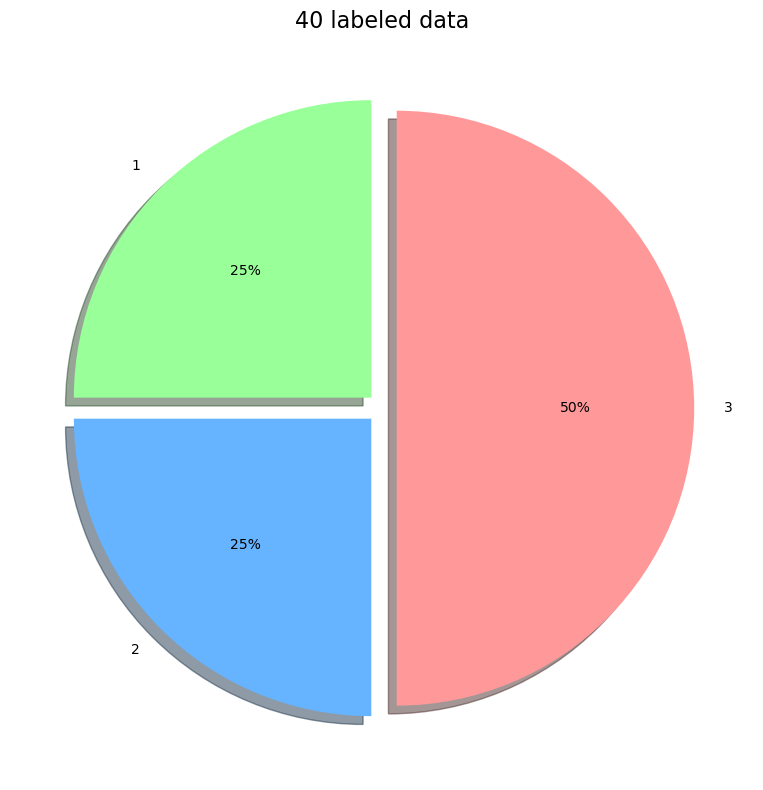

In [5]:
plot_pie_chart(labeled_df,'Label',chart_title='40 labeled data')

**Interpretation:** the label 3 has the half of the labels in the labeled data

### defining a function for drawing a bar chart showing the distribution of the sensors with respect to the labels

In [60]:
def plot_mean_values_by_label(df, features, label_col):
    """
    Plots a grouped bar chart of mean feature values by labels with consistent colors and order.

    Parameters:
    ----------
    df : pd.DataFrame
        Input DataFrame containing the data.
    features : list
        Column names (features) to calculate and plot mean values.
    label_col : str
        Column name for the labels.
    """

    # Define label order and colors
    fixed_order = [1, 2, 3]
    color_mapping = {
        1: '#99ff99', 
        2: '#66b3ff', 
        3: '#ff9999'
    }

    # Compute and reindex mean values by label
    mean_by_label = df.groupby(label_col)[features].mean().reindex(fixed_order)

    # Prepare positions for grouped bars
    x = np.arange(len(features))
    width = 0.25

    # Create the bar chart
    plt.figure(figsize=(10, 8))
    for i, label in enumerate(fixed_order):
        if label not in mean_by_label.index:
            continue
        plt.bar(
            x + i * width,
            mean_by_label.loc[label].fillna(0),
            width,
            label=f"Label {label}",
            color=color_mapping[label]
        )

    # Formatting and display
    plt.xticks(x + width, features, rotation=45)
    plt.ylabel("Mean Value")
    plt.title("Mean Feature Values by Label")
    plt.legend(title="Labels")
    plt.tight_layout()
    plt.show()


### first let's draw a bar chart for ALL the features inside the labeled data to see the discriminations at one glance

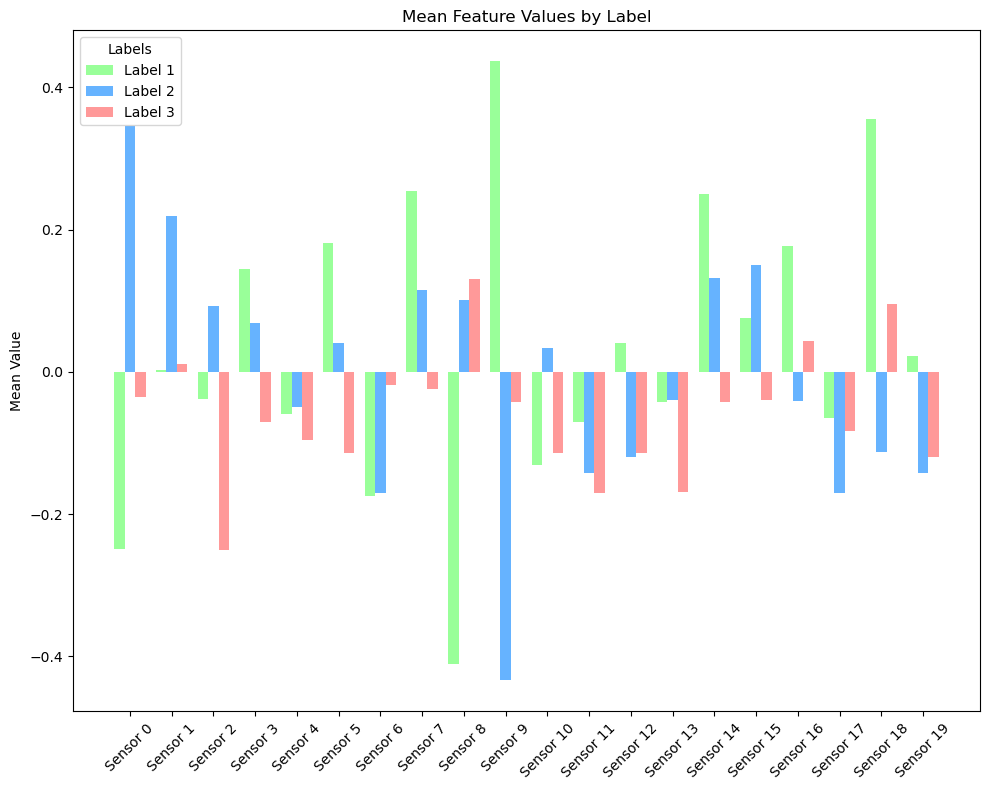

In [61]:
labeled_df['Label'] = labeled_df['Label'].astype('int') # changing the type to int for a bette rrepresentation
plot_mean_values_by_label(labeled_df, features=labeled_df.drop('Label',axis=1).columns, label_col='Label')

**Interpretation:** there are some potential significances! 

### Anova Test: to confirm the significance of the sensors and also rank them with respect to their effect to taraget 

In [28]:
# Anova method
X = labeled_df.drop(columns=["Label"])
y = labeled_df["Label"]

f_values, p_values = f_classif(X, y)

feature_scores = pd.DataFrame({
    "feature": X.columns,
    "f_score": f_values,
    "p_value": p_values
}).sort_values(by="f_score", ascending=False)

# Select top features
top_features = feature_scores.head(5)["feature"].tolist()

print(feature_scores.head(10))
print("Selected features:", top_features)

      feature    f_score       p_value
9    Sensor 9  24.977072  1.364148e-07
8    Sensor 8   2.950636  6.471931e-02
0    Sensor 0   2.725414  7.867522e-02
2    Sensor 2   2.188445  1.263897e-01
18  Sensor 18   1.910704  1.622946e-01
5    Sensor 5   1.107911  3.409552e-01
7    Sensor 7   0.745549  4.814668e-01
14  Sensor 14   0.705648  5.003122e-01
6    Sensor 6   0.487217  6.182198e-01
1    Sensor 1   0.484504  6.198559e-01
Selected features: ['Sensor 9', 'Sensor 8', 'Sensor 0', 'Sensor 2', 'Sensor 18']


**Interpretation:** the top features are listed by their rank, we expected almost the same features to be here! 

### now lets see which top features are the best performing according to Random Forest model with LOOCV method, based on the found features by Anova Test

In [11]:
features_ranked = feature_scores["feature"].tolist()
results = []
for k in range(1, 10):  # try top 1 to top 8
    selected = features_ranked[:k]
    
    X = labeled_df[selected]
    y = labeled_df["Label"]
    
    loo = LeaveOneOut()
    
    y_true, y_pred = [], []
    
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = RandomForestClassifier(n_estimators=1000, random_state=42)
        model.fit(X_train, y_train)
        
        pred = model.predict(X_test)
        
        y_true.append(y_test.values[0])
        y_pred.append(pred[0])
    
    acc = accuracy_score(y_true, y_pred)
    
    results.append((k, acc))

print(results)

[(1, 0.575), (2, 0.475), (3, 0.6), (4, 0.7), (5, 0.75), (6, 0.65), (7, 0.65), (8, 0.65), (9, 0.65)]


**Interpretation:** we see that by choosing the top 5 features we get the best performance: 75% accuracy is about 25 % information gain than the random guessing! 

### We plot the top 5 features chosen by our methodic to observe the significances again more concentrated

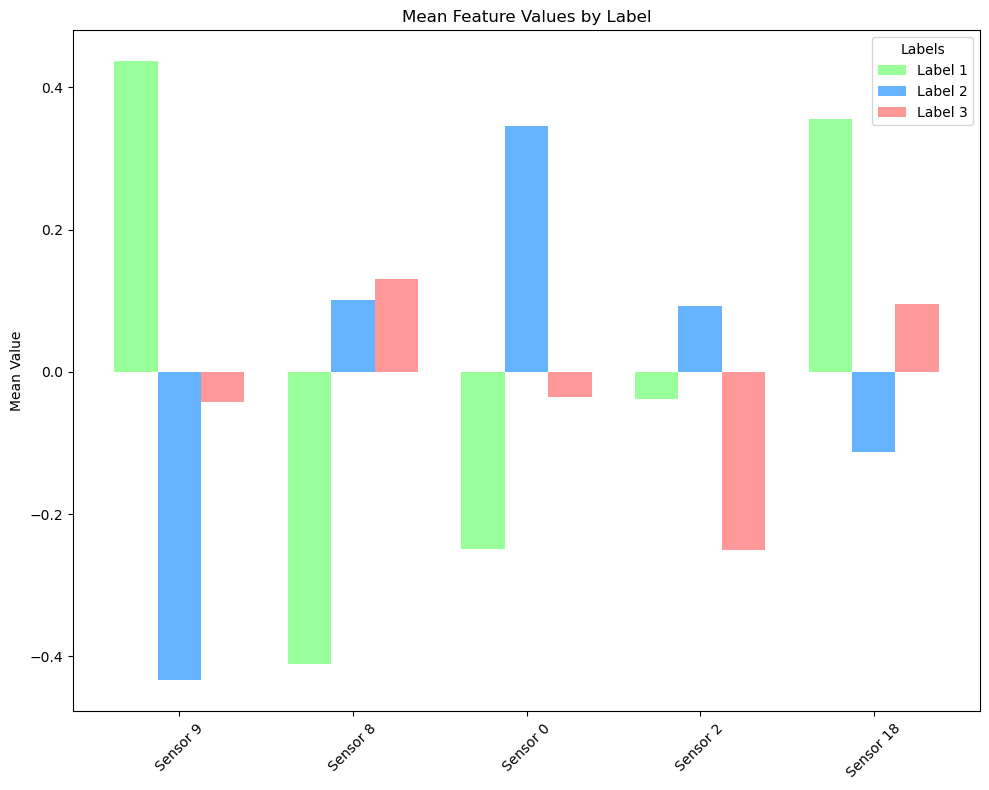

In [62]:
plot_mean_values_by_label(labeled_df, features=top_features, label_col='Label')

**Interpretation:** we see the significant discriminations in these sensors with respect to different labels in the labeled data 

### Just for the matter of comparison we take the Logistic regression model to figure out the most important features, if both models can agree on the chosen features

In [19]:
# now for the confirmation use the LR model to figure out the top features
lr = LogisticRegression(max_iter=1000)
lr.fit(X, y)

coef_df = pd.DataFrame({
    "feature": X.columns,
    "importance": np.abs(lr.coef_).mean(axis=0)
}).sort_values(by="importance", ascending=False)

print(coef_df)

      feature  importance
9    Sensor 9    1.101328
2    Sensor 2    0.586969
5    Sensor 5    0.533296
0    Sensor 0    0.483249
18  Sensor 18    0.444751
6    Sensor 6    0.399191
8    Sensor 8    0.362061
1    Sensor 1    0.267295
15  Sensor 15    0.252130
10  Sensor 10    0.232146
13  Sensor 13    0.210623
17  Sensor 17    0.198337
7    Sensor 7    0.193654
14  Sensor 14    0.179295
19  Sensor 19    0.163702
3    Sensor 3    0.143439
16  Sensor 16    0.116778
4    Sensor 4    0.060703
12  Sensor 12    0.042029
11  Sensor 11    0.014975


**Interpretation:** we can see they are mostly agreeing on the top features! therefore we are good to go with those 5 features

### Another Question: We want to make inferences based on the chosen features. If we compare the distributions of these features in the labeled and unlabeled data across the entire dataset, do they follow the same distribution? This is the key!

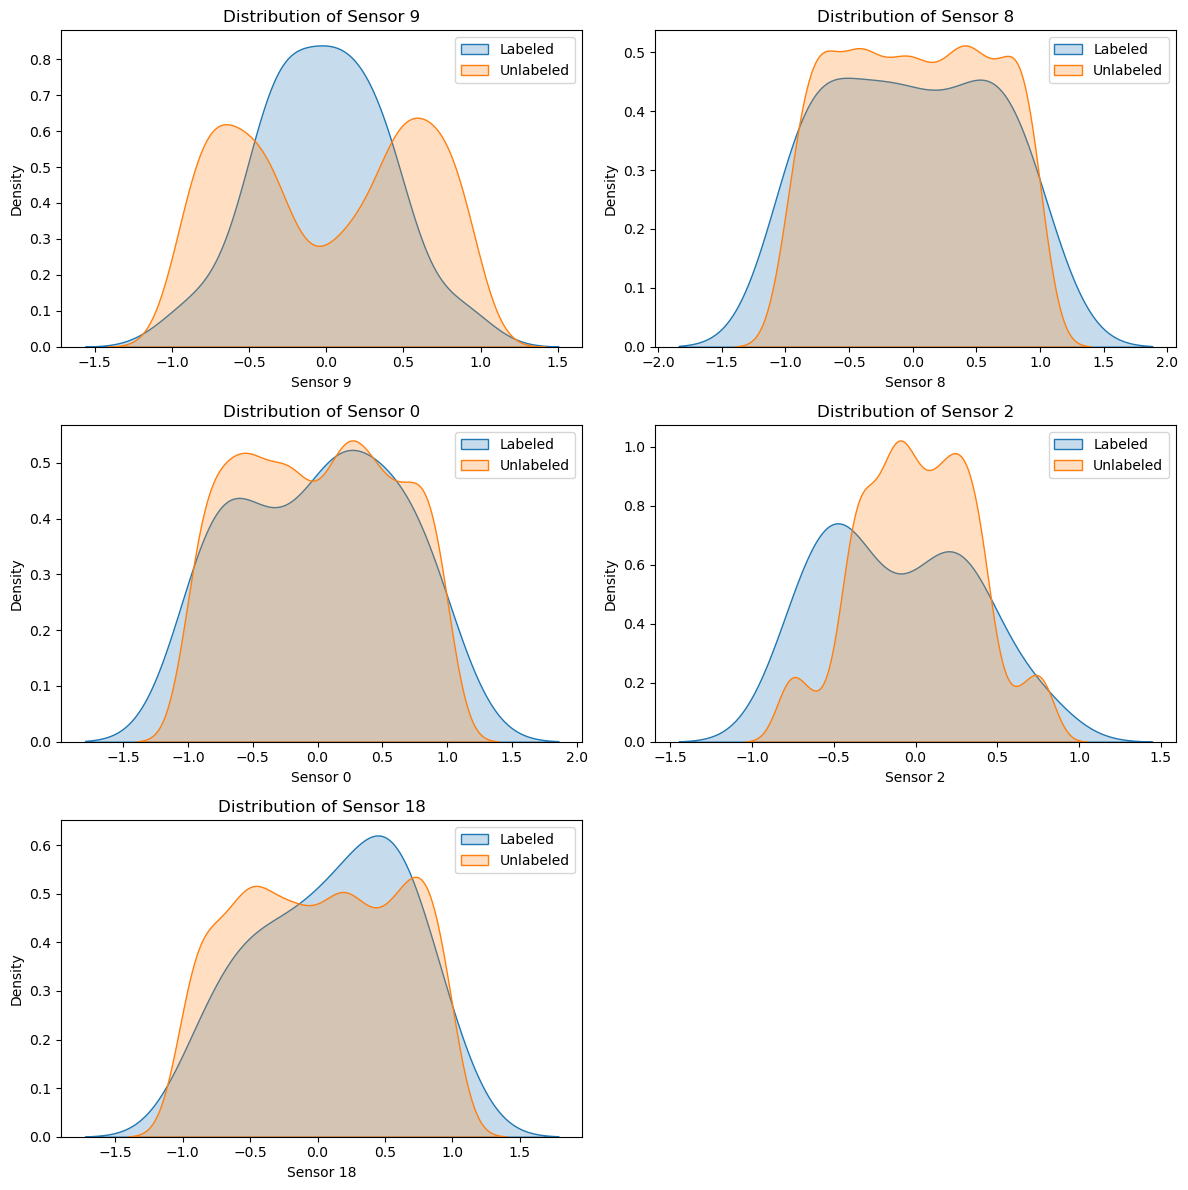

In [13]:
n_features = len(top_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.kdeplot(labeled_df[col], label="Labeled", fill=True, ax=axes[i])
    sns.kdeplot(unlabeled_df[col], label="Unlabeled", fill=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].legend()

# Hide empty subplot(s) if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation:** the distributions mostly seems to be almost identical exepct the sensor9 and sensor2

### KS Test: Statistical test to confirm the distribution comparison accross the entire data between labeled and unlabeled data

In [21]:
# if ks test is significant then the features are coming from different distributions --> it doesn't necessary mean large difference!
for col in top_features:
    stat, p_value = ks_2samp(labeled_df[col], unlabeled_df[col])
    print(f"{col}: p-value = {p_value:.4f}")

Sensor 9: p-value = 0.0064
Sensor 8: p-value = 0.6304
Sensor 0: p-value = 0.9720
Sensor 2: p-value = 0.0032
Sensor 18: p-value = 0.7116
Sensor 5: p-value = 0.3859
Sensor 7: p-value = 0.5240
Sensor 14: p-value = 0.3590
Sensor 6: p-value = 0.3137
Sensor 1: p-value = 0.6034


**Interpretation:** We observe that, based on the KS-test, our initial observation was mostly accurate. However, the fact that the test shows significance for two of the sensors does not necessarily imply large differences in their distributions, as seen in the graphs.

### Training a Random Forest with LOOCV method with top features on the labeled data 

In [31]:
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd

X = labeled_df[top_features]
y = labeled_df["Label"]

loo = LeaveOneOut()

records = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestClassifier(n_estimators=1000, random_state=42)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)[0]
    proba = model.predict_proba(X_test)[0]
    conf = np.max(proba)

    records.append({
        "true_label": y_test.values[0],
        "pred_label": pred,
        "confidence": conf,
        "correct": int(pred == y_test.values[0])
    })

cv_results = pd.DataFrame(records)

# normal evaluation
print("Accuracy:", accuracy_score(cv_results["true_label"], cv_results["pred_label"]))
print(classification_report(cv_results["true_label"], cv_results["pred_label"]))

Accuracy: 0.75
              precision    recall  f1-score   support

           1       0.89      0.80      0.84        10
           2       0.67      0.60      0.63        10
           3       0.73      0.80      0.76        20

    accuracy                           0.75        40
   macro avg       0.76      0.73      0.75        40
weighted avg       0.75      0.75      0.75        40



**Interpretation:** The accuracy is 75%, as expected, which is promising. However, we need to define a probability threshold for the model when it predicts on the unlabeled data. The model should assign a label only if it is highly confident. This threshold should strike a balance by ensuring both good precision and sufficient coverage of the true labels.

### Define the best possible threshold for the probabilities for future predictions

In [32]:
# threshold analysis
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
summary = []

for t in thresholds:
    accepted = cv_results[cv_results["confidence"] >= t]

    coverage = len(accepted) / len(cv_results)
    accuracy = accepted["correct"].mean() if len(accepted) > 0 else np.nan

    summary.append({
        "threshold": t,
        "coverage": coverage,
        "accepted_samples": len(accepted),
        "accuracy_on_accepted": accuracy
    })

threshold_df = pd.DataFrame(summary)
print(threshold_df)

   threshold  coverage  accepted_samples  accuracy_on_accepted
0        0.5     0.925                37              0.729730
1        0.6     0.600                24              0.833333
2        0.7     0.350                14              0.857143
3        0.8     0.225                 9              1.000000
4        0.9     0.075                 3              1.000000


**Interpretation:** for this part we have to align with the business side, however for now I think 0.6 should be the sweet spot for threshold

### Predicting labels on the unlabeled data (1560 data points) with the RF model + Top Features + defined threshold for confidence

In [37]:
X_train = labeled_df[top_features]
y_train = labeled_df["Label"]

# Train Random Forest on all labeled data
rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42
)
rf.fit(X_train, y_train)

# Predict probabilities on unlabeled data
X_unlabeled = unlabeled_df[top_features]

proba = rf.predict_proba(X_unlabeled)                      # shape: (n_samples, n_classes)
max_proba = proba.max(axis=1)                             # confidence per sample
pred_class_idx = proba.argmax(axis=1)                     # index of predicted class
pred_labels = rf.classes_[pred_class_idx]                 # actual predicted labels

# Apply confidence threshold
threshold = 0.6
high_conf_mask = max_proba >= threshold

# Create high-confidence pseudo-labeled group (~40%)
pseudo_labeled_df = unlabeled_df.loc[high_conf_mask].copy()
pseudo_labeled_df["Pseudo_Label"] = pred_labels[high_conf_mask]
pseudo_labeled_df["Prediction_Confidence"] = max_proba[high_conf_mask]

# Keep remaining uncertain unlabeled group (~60%)
remaining_unlabeled_df = unlabeled_df.loc[~high_conf_mask].copy()

# summary
print(f"Total unlabeled samples: {len(unlabeled_df)}")
print(f"High-confidence pseudo-labeled samples: {len(pseudo_labeled_df)}")
print(f"Remaining uncertain unlabeled samples: {len(remaining_unlabeled_df)}")
print(f"Coverage: {len(pseudo_labeled_df) / len(unlabeled_df):.2%}")

print("\nPseudo-label distribution:")
print(pseudo_labeled_df["Pseudo_Label"].value_counts(dropna=False))


Total unlabeled samples: 1560
High-confidence pseudo-labeled samples: 845
Remaining uncertain unlabeled samples: 715
Coverage: 54.17%

Pseudo-label distribution:
Pseudo_Label
1    372
2    290
3    183
Name: count, dtype: int64


**Interpretation:** the result looks promising, since it covers about 54% of the unlabeled (1560) data points

### plotting the distribution of the predictions within the found 845 data points

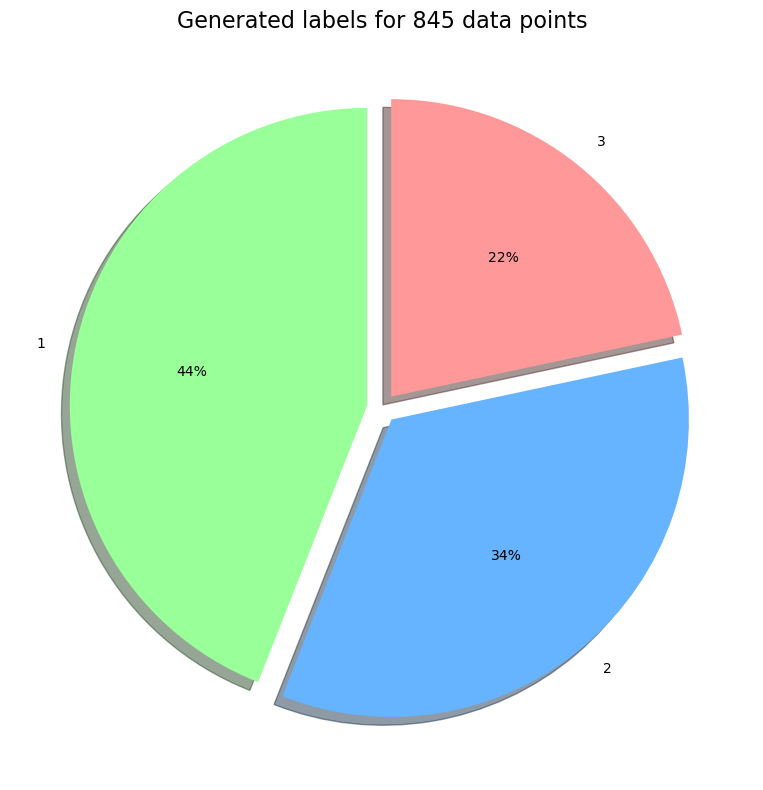

In [38]:
pseudo_labeled_df['Pseudo_Label'] = pseudo_labeled_df['Pseudo_Label'].astype('int') # changing the type to int
plot_pie_chart(pseudo_labeled_df,'Pseudo_Label',chart_title=f'Generated labels for {len(pseudo_labeled_df)} data points')

**Interpretation:** Interestingly, the distribution is slightly different from that of the 40 labeled data points. In the labeled data, 50% of the data points were labeled as label3. However, it is important to note that the labeled dataset was small.

### Evaluation of the Results Using Visualization and Dimensionality Reduction Techniques such as PCA (Principle Component Analysis) and t-SNE

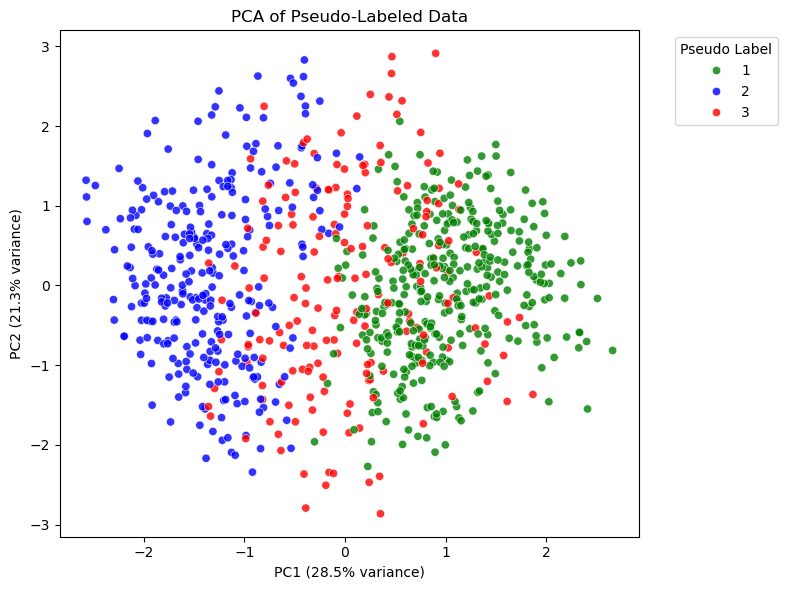

In [64]:
# 1. Prepare pseudo-labeled data
X_pseudo = pseudo_labeled_df[top_features].copy()
y_pseudo = pseudo_labeled_df["Pseudo_Label"].copy()

# 2. Scale features
scaler = StandardScaler()
X_pseudo_scaled = scaler.fit_transform(X_pseudo)

# 3. PCA transformation
pca = PCA(n_components=2, random_state=42)
X_pseudo_pca = pca.fit_transform(X_pseudo_scaled)

# 4. Plot
plt.figure(figsize=(8, 6))

# Define custom color palette for labels 1, 2, and 3
custom_palette = {
    1: "green",  # Label 1 -> Green
    2: "blue",   # Label 2 -> Blue
    3: "red"     # Label 3 -> Red
}

sns.scatterplot(
    x=X_pseudo_pca[:, 0],
    y=X_pseudo_pca[:, 1],
    hue=y_pseudo,
    palette=custom_palette,  # Use custom palette
    alpha=0.8
)

plt.title("PCA of Pseudo-Labeled Data")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Pseudo Label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


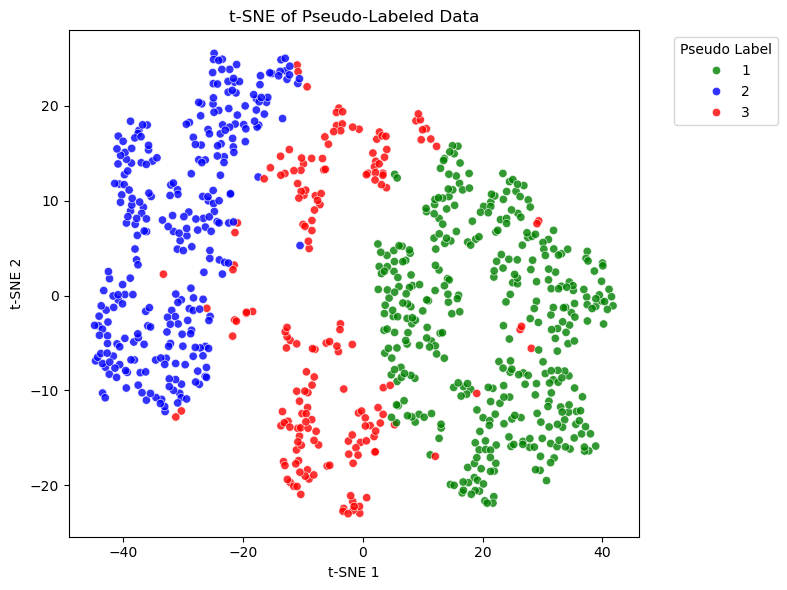

In [53]:
# 1. Prepare pseudo-labeled data
X_pseudo = pseudo_labeled_df[top_features]
y_pseudo = pseudo_labeled_df["Pseudo_Label"]

X_pseudo_scaled = scaler.transform(X_pseudo)

# 2. t-SNE transformation
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_pseudo_tsne = tsne.fit_transform(X_pseudo_scaled)

# 3. Plot
plt.figure(figsize=(8, 6))

# Define custom color palette for labels 1, 2, and 3
custom_palette = {
    1: "green",  # Label 1 -> Green
    2: "blue",   # Label 2 -> Blue
    3: "red"     # Label 3 -> Red
}

sns.scatterplot(
    x=X_pseudo_tsne[:, 0],
    y=X_pseudo_tsne[:, 1],
    hue=y_pseudo,
    palette=custom_palette,  # Use custom palette
    alpha=0.8
)

plt.title("t-SNE of Pseudo-Labeled Data")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Pseudo Label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Interpretation:** PCA shows partial separation between classes, with overlap particularly for class 3, while t-SNE highlights clearer local clusters, revealing coherent groupings within the data.

### Validating the Pseudo Labels Using Cosine Similarity
We set a threshold for Cosine Similarity (e.g., 0.6) and a minimum number of matches (e.g., 4) to verify the pseudo labels. For each pseudo-labeled data point, we compare its top features with all 40 labeled data points. If at least 4 labeled points with the same label have a similarity score above 0.6, we consider the pseudo label to be reliable and similar to the labeled data.

In [42]:

# 1. Setup
features = top_features
k = 4 # top-k neighbors
similarity_threshold = 0.6 # you can tune this

# 2. Prepare data
X_labeled = labeled_df[features]
y_labeled = labeled_df["Label"]

X_pseudo = pseudo_labeled_df[features]
pseudo_labels = pseudo_labeled_df["Pseudo_Label"].values

# Scale (important for cosine!)
scaler = StandardScaler()
X_labeled_scaled = scaler.fit_transform(X_labeled)
X_pseudo_scaled = scaler.transform(X_pseudo)

# Convert labeled to DataFrame for filtering
labeled_scaled_df = pd.DataFrame(X_labeled_scaled, columns=features)
labeled_scaled_df["Label"] = y_labeled.values

# -----------------------------
# 3. Validate pseudo-labels
# -----------------------------
accepted_mask = []
avg_similarities = []

for i in range(len(X_pseudo_scaled)):
    sample = X_pseudo_scaled[i].reshape(1, -1)
    pred_label = pseudo_labels[i]

    # Take only labeled samples of predicted class
    class_samples = labeled_scaled_df[labeled_scaled_df["Label"] == pred_label][features].values

    # Compute cosine similarity
    sims = cosine_similarity(sample, class_samples)[0]

    # Take top-k similarities
    top_k = np.sort(sims)[-k:]
    avg_sim = np.mean(top_k)

    avg_similarities.append(avg_sim)

    # Accept or reject
    accepted_mask.append(avg_sim >= similarity_threshold)

# -----------------------------
# 4. Create filtered dataset
# -----------------------------
pseudo_labeled_df = pseudo_labeled_df.copy()
pseudo_labeled_df["avg_similarity"] = avg_similarities
pseudo_labeled_df["accepted_by_similarity"] = accepted_mask

filtered_pseudo_df = pseudo_labeled_df[pseudo_labeled_df["accepted_by_similarity"]]

# -----------------------------
# 5. Results
# -----------------------------
print(f"Original pseudo-labeled samples: {len(pseudo_labeled_df)}")
print(f"Accepted after similarity filtering: {len(filtered_pseudo_df)}")
print(f"Acceptance rate: {len(filtered_pseudo_df) / len(pseudo_labeled_df):.2%}")

print("\nDistribution after filtering:")
print(filtered_pseudo_df["Pseudo_Label"].value_counts())

Original pseudo-labeled samples: 845
Accepted after similarity filtering: 728
Acceptance rate: 86.15%

Distribution after filtering:
Pseudo_Label
1    292
2    278
3    158
Name: count, dtype: int64


**Interpretation:** the result looks promising, it means with those defined parameters we got about 86% of agreement between the predicted labels and the similarity check, however let's see if this result is by chance or not?

### Checking for Randomness by Shuffling Pseudo Labels and Using Cosine Similarity
To verify if the observed results were truly significant and not random, we shuffle the predicted labels twice and rerun the similarity check conducted earlier. If the agreement seen previously does not appear after shuffling, it indicates that the original results were meaningful and not due to random chance.

In [43]:
# ----------------------------------------
# Configuration of the experiment
# ----------------------------------------

# Features used for similarity comparison (your selected top features)
features = top_features

# Number of nearest neighbors to consider for similarity
k = 4

# Minimum similarity required to accept a pseudo-label
similarity_threshold = 0.6

# Number of times we shuffle labels for the sanity check
n_shuffles = 2


# ----------------------------------------
# Prepare and scale the data
# ----------------------------------------

# Extract relevant features from labeled and pseudo-labeled datasets
X_labeled = labeled_df[features].copy()
y_labeled = labeled_df["Label"].copy()

X_pseudo = pseudo_labeled_df[features].copy()
pseudo_labels = pseudo_labeled_df["Pseudo_Label"].copy()

# Scale the data so that all features contribute equally to similarity
scaler = StandardScaler()
X_labeled_scaled = scaler.fit_transform(X_labeled)
X_pseudo_scaled = scaler.transform(X_pseudo)

# Store scaled labeled data in a dataframe for easier filtering by class
labeled_scaled_df = pd.DataFrame(X_labeled_scaled, columns=features)
labeled_scaled_df["Label"] = y_labeled.values


# ----------------------------------------
# Function: Validate pseudo-labels using similarity
# ----------------------------------------

def compute_acceptance(pseudo_labels_series):
    """
    For each pseudo-labeled sample:
    - Compare it to labeled samples of the same predicted class
    - Compute cosine similarity
    - Take the top-k most similar labeled samples
    - Accept the label if the average similarity is above a threshold
    """

    accepted_mask = []       # True/False: whether each sample is accepted
    avg_similarities = []    # Average similarity score per sample

    for i in range(len(X_pseudo_scaled)):
        # Take one pseudo sample
        sample = X_pseudo_scaled[i].reshape(1, -1)

        # Get its predicted label
        pred_label = pseudo_labels_series.iloc[i]

        # Select labeled samples that belong to the same class
        class_samples = labeled_scaled_df[
            labeled_scaled_df["Label"] == pred_label
        ][features].values

        # Compute cosine similarity between the sample and all class samples
        sims = cosine_similarity(sample, class_samples)[0]

        # Take the top-k most similar samples
        top_k = np.sort(sims)[-k:]

        # Compute average similarity
        avg_sim = np.mean(top_k)

        avg_similarities.append(avg_sim)

        # Accept if similarity is high enough
        accepted_mask.append(avg_sim >= similarity_threshold)

    return np.array(accepted_mask), np.array(avg_similarities)


# ----------------------------------------
# Step 1: Evaluate original pseudo-labels
# ----------------------------------------

orig_accept_mask, orig_avg_sims = compute_acceptance(
    pseudo_labels.reset_index(drop=True)
)

original_accepted = orig_accept_mask.sum()
original_rate = orig_accept_mask.mean()

print(f"Original accepted samples: {original_accepted}")
print(f"Original acceptance rate: {original_rate:.3f}")


# ----------------------------------------
# Step 2: Shuffle labels to test randomness
# ----------------------------------------

shuffle_results = []

pseudo_labels_reset = pseudo_labels.reset_index(drop=True)

for i in range(n_shuffles):
    # Randomly shuffle the labels (breaks real structure)
    shuffled_labels = pd.Series(
        np.random.permutation(pseudo_labels_reset.values)
    )

    # Compute acceptance again with shuffled labels
    shuf_accept_mask, shuf_avg_sims = compute_acceptance(shuffled_labels)

    shuffle_results.append({
        "shuffle_run": i + 1,
        "accepted_samples": int(shuf_accept_mask.sum()),
        "acceptance_rate": float(shuf_accept_mask.mean())
    })

shuffle_results_df = pd.DataFrame(shuffle_results)


# ----------------------------------------
# Step 3: Compare original vs random
# ----------------------------------------

print("\nShuffled acceptance results:")
print(shuffle_results_df)

print("\nSummary:")
print(f"Original acceptance rate: {original_rate:.3f}")
print(f"Mean shuffled acceptance rate: {shuffle_results_df['acceptance_rate'].mean():.3f}")

Original accepted samples: 728
Original acceptance rate: 0.862

Shuffled acceptance results:
   shuffle_run  accepted_samples  acceptance_rate
0            1               280         0.331361
1            2               283         0.334911

Summary:
Original acceptance rate: 0.862
Mean shuffled acceptance rate: 0.333


**Interpretation:** This experiment shows that the observed results were not due to chance, and the pseudo labels are indeed closely aligned with their corresponding labels from the training data.

## Clustering the Remaining Unlabeled Data --> 44% of the entire data
We use the K-means method, an unsupervised learning technique, to cluster the remaining 44% of unlabeled data. This helps uncover hidden patterns in the data, which we can then compare with the patterns from the labeled data.

there is also a method for finding out the best number of clusters which is called Elbow technique:

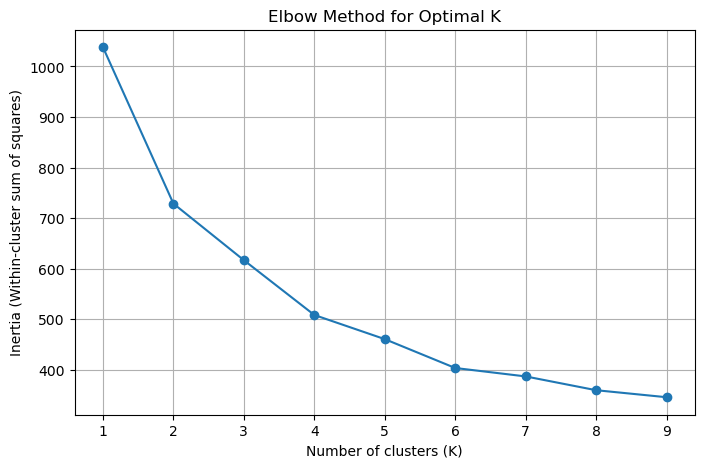

In [23]:
# Use only the uncertain data and selected features
X_uncertain = remaining_unlabeled_df[top_features]

# Compute inertia for different K
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_uncertain)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (Within-cluster sum of squares)")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

**Interpretation:** Using the elbow method, I selected K=4 as the optimal number of clusters for the uncertain data. Interestingly, this exceeds the number of known failure types, suggesting that the unlabeled data may contain additional structure or previously unobserved failure modes

### Training Clustering model with 4 number clusters (Kmeans)

In [46]:
# 1. Fit KMeans on uncertain data
X_uncertain = remaining_unlabeled_df[top_features].copy()

kmeans = KMeans(n_clusters=4, random_state=42)
remaining_unlabeled_df["cluster"] = kmeans.fit_predict(X_uncertain)

### How is the distribution of the found clusters across unlabeled data points? 

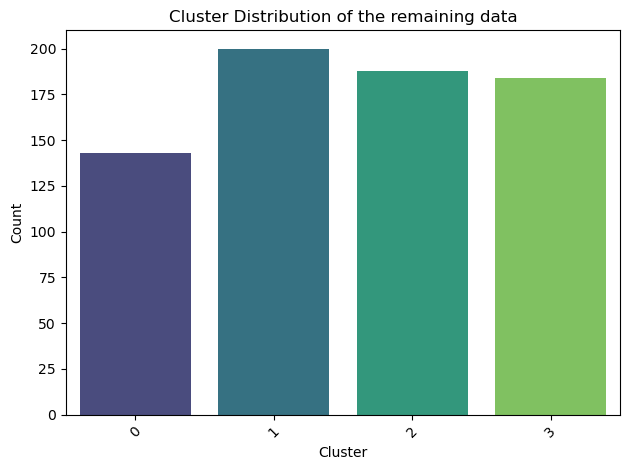

In [47]:

# Count the occurrences in the 'cluster' column
cluster_counts = remaining_unlabeled_df['cluster'].value_counts()

# Make a bar plot using seaborn
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')

# Add labels
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Cluster Distribution of the remaining data')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability (if needed)

# Show the plot
plt.tight_layout()  # Ensure everything fits without overlap
plt.show()


**Interpretation:** as we observe here there is no big difference between number of data points among clusters

### Identifying Patterns in the Clusters
We aim to uncover similarities within each cluster by comparing them to the labeled data based on their top features. To achieve this, we use a statistical test, such as the KS test, to check if the distributions are identical. Additionally, we use a heatmap to visualize the similarity matrix of clusters against the labeled data, where each cell indicates the number of similar features.

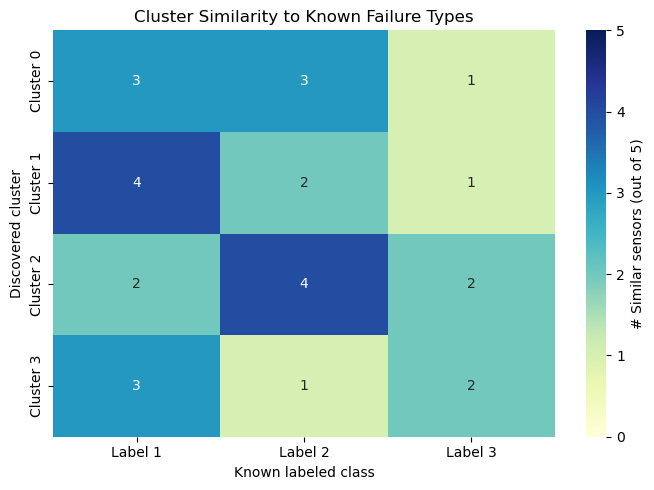

      cluster    label  similar_count                         similar_features
0   Cluster 0  Label 1              3             Sensor 9, Sensor 0, Sensor 2
1   Cluster 0  Label 2              3            Sensor 8, Sensor 2, Sensor 18
2   Cluster 0  Label 3              1                                 Sensor 8
3   Cluster 1  Label 1              4  Sensor 8, Sensor 0, Sensor 2, Sensor 18
4   Cluster 1  Label 2              2                      Sensor 2, Sensor 18
5   Cluster 1  Label 3              1                                Sensor 18
6   Cluster 2  Label 1              2                       Sensor 9, Sensor 2
7   Cluster 2  Label 2              4  Sensor 8, Sensor 0, Sensor 2, Sensor 18
8   Cluster 2  Label 3              2                      Sensor 8, Sensor 18
9   Cluster 3  Label 1              3            Sensor 0, Sensor 2, Sensor 18
10  Cluster 3  Label 2              1                                 Sensor 2
11  Cluster 3  Label 3              2               

In [50]:
# This code compares each discovered cluster with each known label.
# For every top feature, it checks whether the feature distribution in the cluster
# is statistically similar to the corresponding distribution in the labeled data.
# In the end, it creates a heatmap showing how many features are similar
# between each cluster and each known label.

rows = []

# Go through all discovered clusters one by one
for cluster_id in sorted(remaining_unlabeled_df["cluster"].unique()):
    cluster_data = remaining_unlabeled_df[
        remaining_unlabeled_df["cluster"] == cluster_id
    ]

    # Compare the current cluster with each known label from the labeled data
    for label in sorted(labeled_df["Label"].unique()):
        label_data = labeled_df[labeled_df["Label"] == label]

        similar_features = 0
        similar_feature_names = []

        # For each top feature, run a KS test to compare the distributions
        for col in top_features:
            stat, p = ks_2samp(cluster_data[col], label_data[col])

            # If p >= 0.05, we treat the two distributions as similar
            if p >= 0.05:
                similar_features += 1
                similar_feature_names.append(col)

        # Store the result for this cluster-label comparison
        rows.append({
            "cluster": f"Cluster {cluster_id}",
            "label": f"Label {int(label)}",
            "similar_count": similar_features,
            "similar_features": ", ".join(similar_feature_names) if similar_feature_names else "-"
        })

# Convert the collected results into a dataframe
summary_df = pd.DataFrame(rows)

# Reshape the table so it can be shown as a heatmap
# Rows = clusters, columns = labels, values = number of similar features
heatmap_data = summary_df.pivot(
    index="cluster",
    columns="label",
    values="similar_count"
)

# Plot the heatmap
# Darker color means more similar features between a cluster and a label
plt.figure(figsize=(7, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    vmin=0,
    vmax=len(top_features),
    cbar_kws={"label": f"# Similar sensors (out of {len(top_features)})"}
)

plt.title("Cluster Similarity to Known Failure Types")
plt.xlabel("Known labeled class")
plt.ylabel("Discovered cluster")
plt.tight_layout()
plt.show()

# Also print the detailed table showing exactly which features are similar
print(summary_df.sort_values(["cluster", "label"]))

### **Interpretation**  
From the heatmap, we can draw the following insights:

1. **Clusters capture variations of known failure types.**  
2. **Failure Type 1** is divided into multiple subtypes.  
3. **Failure Type 2** also consists of multiple subtypes.  
4. Some data points lie **between two failure types**, suggesting overlap or uncertainty.  
5. **Failure Type 3** is less represented in the uncertain data.  


# Conclusion

In this use case, we addressed the challenge of extracting meaningful insights from a largely unlabeled dataset of machine breakdown events. With only a small fraction of labeled data available, a hybrid semi-supervised approach was applied to bridge the gap between limited expert knowledge and a large volume of sensor data.

By identifying the most informative sensors and training a robust model with careful validation, we were able to extend labels to a significant portion of the dataset. The pseudo-labeling process was further validated using similarity-based methods, ensuring that the assigned labels align with known patterns rather than random behavior.

For the remaining uncertain data, clustering techniques revealed additional structure. These clusters did not represent entirely new failure types, but rather highlighted subtypes and overlapping patterns within existing categories. This insight suggests that failure types are not strictly homogeneous and can benefit from further refinement.

Overall, this approach demonstrates how combining supervised learning, similarity validation, and clustering can:
- Scale expert knowledge across large datasets  
- Improve understanding of system behavior  
- Identify hidden structure and ambiguity in the data  

From a practical perspective, the solution provides a foundation for automated diagnostics, supports expert decision-making, and enables continuous improvement through feedback loops. It illustrates how machine learning can transform limited labeled data into actionable and scalable insights for industrial applications.